## 📚 Índice do Notebook

1. [🗃️ Visualização e Análise Inicial dos Dados](#-visualização-e-análise-inicial-dos-dados)
   - [📊 O que é analisado?](#-o-que-é-analisado)
   - [🌧️ Distribuição](#-distribuição)
   - [🎯 P90](#-p90)
   - [📊🆚📊 Dupla Massa](#-dupla-massa)
2. [🔗 Análise de Correlação da Precipitação](#-análise-de-correlação-da-precipitação)
3. [📈 Análise de Tendência da Precipitação](#-análise-de-tendencia-da-precipitação)
4. [📊 Distribuição Estatística da Precipitação](#-distribuição-estatística-da-precipitação)


# 📊 Automatic IDF Graphs – Análise de Qualidade e Exploração de Dados

Este notebook realiza a análise de qualidade e a exploração estatística das séries de precipitação.

🎯 Objetivo: Validar a consistência e entender as características dos dados antes de avançar para a modelagem de curvas IDF.

<br>

## 🛠️ O que este notebook faz?

Neste notebook, vamos:

- 🔍 Importar e explorar dados de exemplo  
- 📚 Demonstrar as principais funções da biblioteca  
- 📊 Gerar gráficos e curvas IDF com base em dados reais  
- ✅ Validar resultados com visualizações claras  

#### Continuaremos seguindo o passo a passo claro. Para isso, teremos que resgatar algumas funções do notebook anterior:

In [13]:
from idf_analysis.data.processing import read_csv, fill_missing_data

# Captando os dados
cemaden_df = read_csv(path='../results/cemaden_ac_santana_sao/cemaden_ac_santana_sao_hourly.csv')
inmet_df = read_csv(path='../results/inmet_sao_paulo_mirante/inmet_sao_paulo_mirante_hourly.csv')
inmet_daily_df = read_csv(path='../results/inmet_daily_sao_paulo_mirante/inmet_daily_sao_paulo_mirante_daily.csv')
climbra_hist_df = read_csv(path='../results/CABra467/historical/1980-2013_daily.csv')

# Preenchendo falhas
cemaden_df = fill_missing_data(df_main=cemaden_df,
                               df_secondary=inmet_df,
                               frequency='hourly',)

---
## 🗃️ Visualização e Análise Inicial dos Dados

Antes de ajustar modelos ou gerar curvas, é essencial entender o comportamento bruto da precipitação.

### 📊 O que é analisado?

- **Distribuição dos dados (histograma)**  
  Visualiza como os valores de chuva se espalham — identifica padrões e extremos.

- **P90 (Percentil 90%)**  
  Valor acima do qual estão os 10% maiores registros. Indica eventos intensos.

- **Gráfico de Dupla Massa**  
  Compara o acumulado de uma estação com a média das demais. Verifica a consistência dos dados.

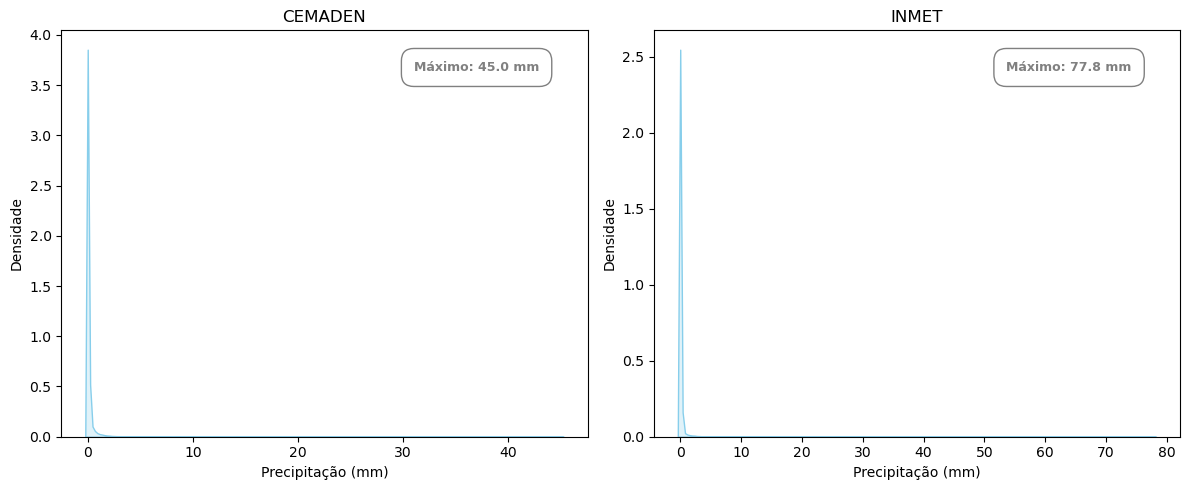

In [3]:

from idf_analysis.visualization.plots import distribution_plot_df
from idf_analysis.analysis.historical.validation import p90, process_precipitation_series
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

distribution_plot_df(df=cemaden_df, show_max=True, ax=axes[0], display=False)
axes[0].set_title("CEMADEN")

distribution_plot_df(df=inmet_df, show_max=True, ax=axes[1], display=False)
axes[1].set_title("INMET")

plt.tight_layout()
plt.show()

### 🎯 P90

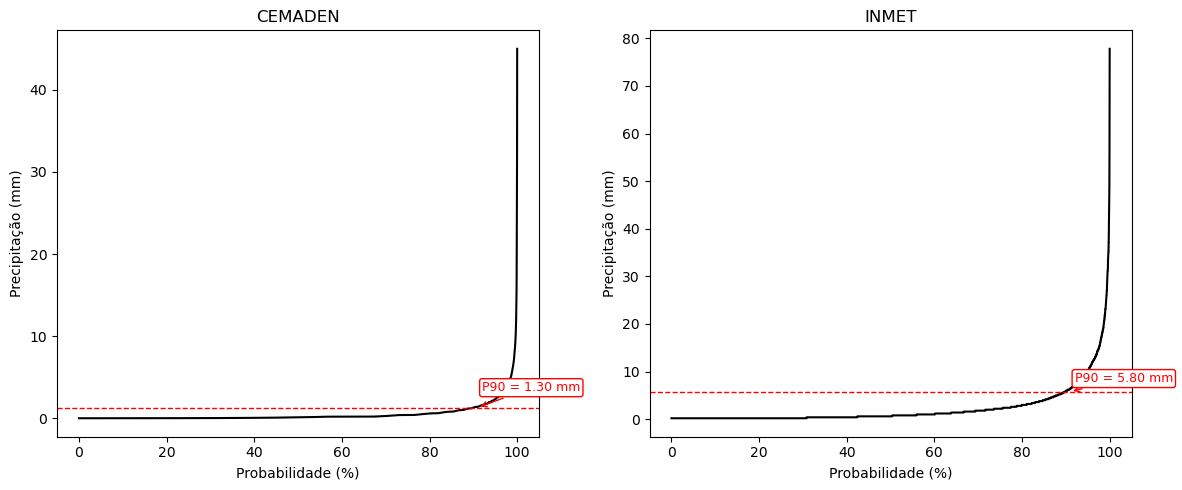

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

_, ax1 = p90(cemaden_df, ax=axes[0], display=False)
axes[0].set_title("CEMADEN")

_, ax2 = p90(inmet_df, ax=axes[1], display=False)
axes[1].set_title("INMET")

plt.tight_layout()
plt.show()

### 📊🆚📊 Cálculo de dupla massa

[OK] Série completa! Nenhum período faltando.

[OK] Série completa! Nenhum período faltando.



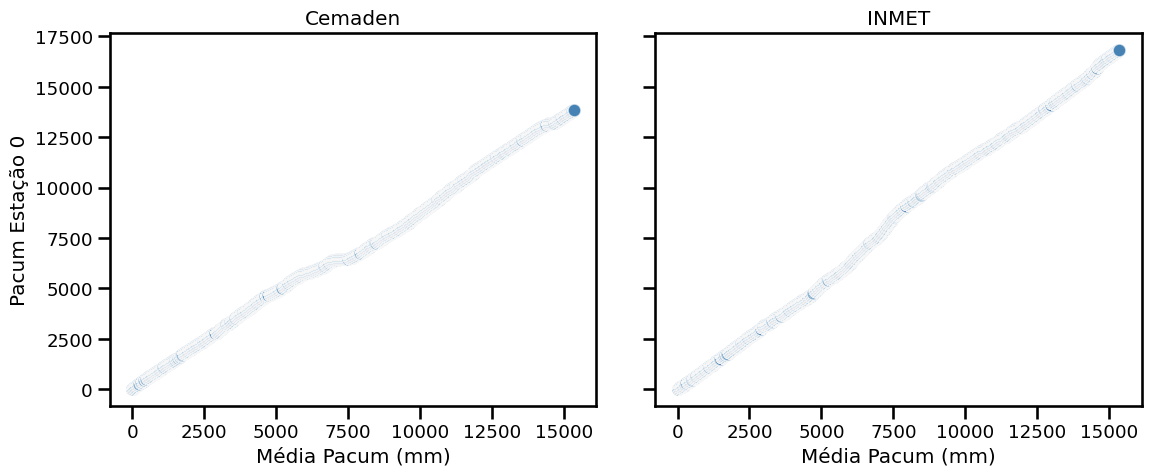

In [5]:
df, (fig, axes) = process_precipitation_series(dataframes=[cemaden_df,inmet_df],
                                plot=False, return_fig=True, frequency='hourly')

axes[0].set_title("Cemaden")
axes[1].set_title("INMET")
plt.tight_layout()
plt.show()

---
## 🔗 Análise de Correlação da Precipitação

### 🎯 Objetivo
Avaliar **o grau de relação** entre séries de precipitação de diferentes estações meteorológicas.  
Essa análise ajuda a:

- Identificar **sincronização de eventos de chuva**.  
- Detectar **redundância ou complementaridade** entre séries.  
- Avaliar **significância estatística** da correlação.

### ⚙️ Como Funciona

1. **📅 Combinação de Séries**  
   - Junta os DataFrames pela coluna/índice `Date`.  
   - Soma valores para datas repetidas (ex.: dados horários → diários).  

2. **📈 Visualização Gráfica**  
   - Gera **pairplots** para analisar dispersão entre as séries.  
   - Pode aplicar **transformação logarítmica** e **linha de regressão** para melhor interpretação.  

3. **🧮 Cálculo Estatístico**  
   - **Matriz de Correlação (r de Pearson)**: mede força da relação linear.  
   - **Matriz de P-valores**: avalia se a correlação é estatisticamente significativa.  

[INFO] Dados horários detectados → agregando para diário...
[INFO] Gerando scatter/regression com 4019 pontos...


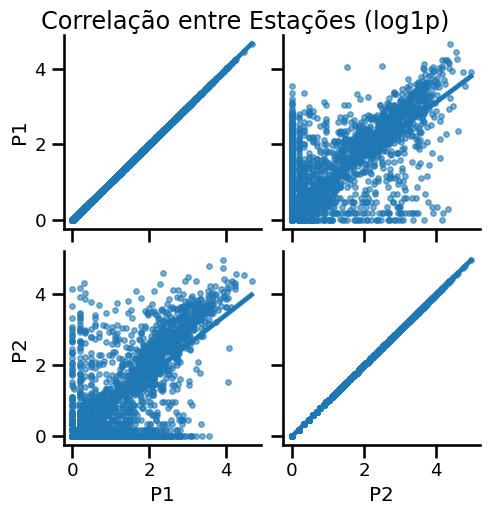


[INFO] ----- Resultados da Correlação -----

Matriz de Correlação (r de Pearson):
       P1     P2
P1 1.0000 0.7641
P2 0.7641 1.0000

Matriz de P-valores:
           P1         P2
P1 1.0000e+00 0.0000e+00
P2 0.0000e+00 1.0000e+00


In [6]:
from idf_analysis.core.correlation import correlation_plots

correlation_plots(cemaden_df, inmet_df);

---
## 📈 Análise de Tendência da Precipitação

### 🎯 Objetivo
Detectar **mudanças sistemáticas** nos padrões de precipitação ao longo do tempo.  
Identifica tendências de longo prazo e avalia sua significância estatística.

### ⚙️ Como Funciona

1. **🧹 Preparação**: Limpa séries temporais e remove valores ausentes.

2. **📊 Testes Mann-Kendall**: Aplica 5 variações do teste para detectar tendências monotônicas:
  - *Original, Hamed-Rao, Yue-Wang, Pre-whitening, Trend-free*

3. **📈 Quantificação**: Calcula Sen's Slope (mm/ano), Tau de Kendall e intervalos de confiança.

4. **🎨 Visualização**: Gráficos de tendência com análise de resíduos e comparações estatísticas.

### 📋 Resultados
- Direção da tendência (crescente/decrescente/sem tendência)
- Significância estatística (p-valor)
- Magnitude da mudança (Sen's slope em mm/ano)
- Comparação entre diferentes metodologias

### ⚠️ Considerações
- **Dados Mínimos**: recomendado ≥20 anos para análise robusta
- **Autocorrelação**: pode inflacionar significância (use testes corrigidos)
- **Outliers**: eventos extremos podem mascarear tendências reais
- **Sazonalidade**: dados anuais reduzem interferência sazonal
- **Múltiplos Testes**: considere correção de Bonferroni para análises em larga escala

In [7]:
from idf_analysis.analysis.historical.validation import max_annual_precipitation
from idf_analysis.analysis.historical.trend import run_trend_analysis,filter_significant_results



# Essa função será detalhada no próximo notebook
max_annual_inmet_daily = max_annual_precipitation(df=inmet_daily_df, name_file='cemaden_ac_santana_sao', output_dir='../results/cemaden_ac_santana_sao/', frequency='hourly')
max_annual_climbra_hist = max_annual_precipitation(df=climbra_hist_df, name_file='inmet_sao_paulo_mirante', output_dir='../results/inmet_sao_paulo_mirante/', frequency='hourly')

results_df, stats = run_trend_analysis(
    {
        'CLIMBra Histórico': max_annual_climbra_hist,
        'INMET': max_annual_inmet_daily
    }, 
    generate_plots=True,
    output_dir='../results/graphs/trend'
)

# Apenas resultados significativos
significant = filter_significant_results(results_df)

display(significant)


[INFO] Gráficos salvos em: ../results/graphs/trend



,station,test_type,tau,p_value,trend,significant,z_score,s_statistic,variance_s,slope,intercept,ci_lower,ci_upper
7,INMET,yue_wang,0.210227,0.000013,increasing,True,4.360765,111.0,636.297309,0.784286,70.251429,-5.917987,7.486559


---
## 📊 Distribuição Estatística da Precipitação

### 🎯 O que é?

A **distribuição estatística** representa como os valores de precipitação se distribuem ao longo do tempo. Ela é fundamental para compreender a variabilidade dos dados e identificar padrões, tendências e eventos extremos.

### ⏱️ Tipos de Análise

1. **📅 Dados Diários**  
   - Utilizam os totais registrados por dia.  
   - Não exigem parametrização adicional.

2. **🕒 Dados Subdiários (Desagregados)**  
   - Requerem:
     - Um **fator de desagregação** apropriado.
     - A **duração alvo** a ser analisada (ex.: 15 min, 1 h, etc.).

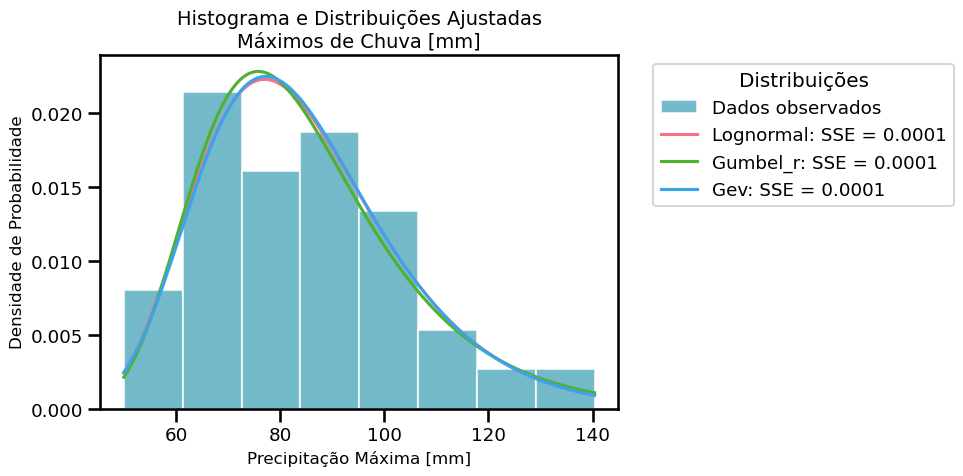

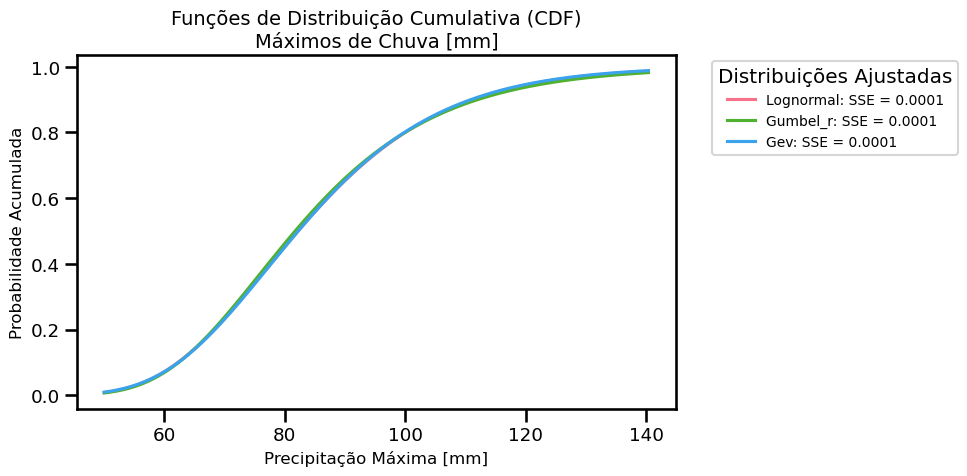

In [9]:
from idf_analysis.core.distributions import get_distribution
import warnings
warnings.filterwarnings('ignore')

# Obtendo a distribuição estatística dos dados diários
get_distribution(data_df=max_annual_inmet_daily,column_name='Precipitation')



[OK] Resultados salvos em: ../results/inmet_sao_paulo_mirante/max_subdaily_inmet_sao_paulo_mirante.csv


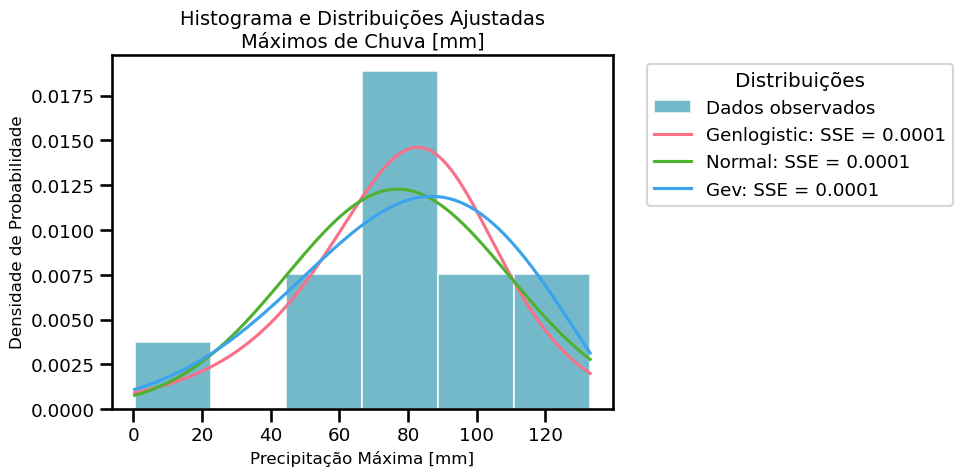

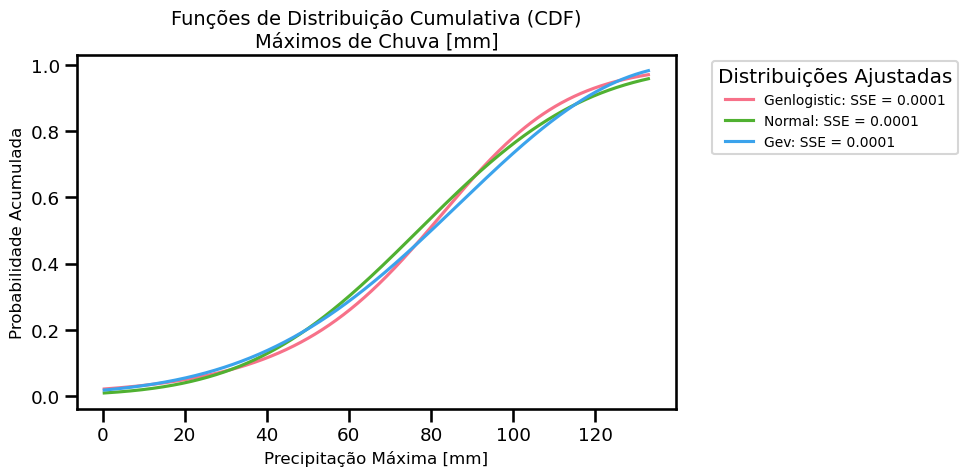

In [12]:
from idf_analysis.analysis.historical.subdaily import get_max_subdaily_table

# Essa função será detalhada no próximo notebook
subdaily_inmet = get_max_subdaily_table(df=inmet_df, name_file='inmet_sao_paulo_mirante', output_dir='../results/inmet_sao_paulo_mirante')

# Obtendo a distribuição estatística dos dados subdiários
get_distribution(data_df=subdaily_inmet,
                 column_name='Max_12h')